In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import yfinance as yf


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,12_ema,27_ema,MACD,Signal,MACD_hist,...,Money_Flow,Pos_Flow,Neg_Flow,MFI,MACD_Strategy,MFI_Strategy,Full_Strategy,Strategy,Asset_Returns,Strategy_Returns
13,121.461098,132.041713,117.283667,121.087374,3743115,144.398738,150.359441,-5.960703,-2.952256,-3.008447,...,4.626321e+08,0.000000,123.595493,74.649907,NaN,NaN,NaN,0,NaN,NaN
14,127.307877,129.973798,123.745022,123.745022,1696795,141.535726,147.905486,-6.369760,-3.660683,-2.709078,...,2.155081e+08,127.008899,0.000000,70.245974,1.0,-1.0,0.0,0,0.048137,0.000000
15,132.556686,134.342264,125.406050,127.565364,3101715,140.051869,146.326825,-6.274956,-4.198681,-2.076275,...,4.056061e+08,130.768333,0.000000,71.266563,1.0,-1.0,0.0,0,0.091351,0.000000
16,134.217697,138.195804,131.717886,132.880586,3009285,139.098604,145.119316,-6.020712,-4.571481,-1.449230,...,4.053822e+08,134.710462,0.000000,72.510759,1.0,-1.0,0.0,0,0.105026,0.000000
17,130.845810,135.330523,128.769551,134.541547,1888275,137.762905,143.735137,-5.972232,-4.856771,-1.115461,...,2.485888e+08,0.000000,131.648628,80.726945,1.0,-1.0,0.0,0,0.077265,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6297,184.860001,195.910004,183.520004,189.990005,7376659,181.456882,167.587472,13.869409,15.017783,-1.148373,...,1.387525e+09,188.096670,0.000000,41.831925,1.0,0.0,1.0,0,0.521969,-0.331776
6298,188.559998,193.000000,182.330002,190.000000,6524220,182.549669,169.085510,13.464159,14.707058,-1.242899,...,1.226314e+09,0.000000,187.963333,42.441211,1.0,0.0,1.0,0,0.552431,-0.331776
6299,173.199997,185.479996,170.020004,185.000000,5221474,181.111258,169.379402,11.731856,14.112018,-2.380162,...,9.201978e+08,0.000000,176.233332,49.180101,1.0,0.0,1.0,0,0.425971,-0.331776
6300,180.020004,183.000000,175.509995,179.000000,4628775,180.943372,170.139445,10.803928,13.450400,-2.646472,...,8.309114e+08,179.510000,0.000000,42.478172,1.0,0.0,1.0,0,0.482121,-0.331776


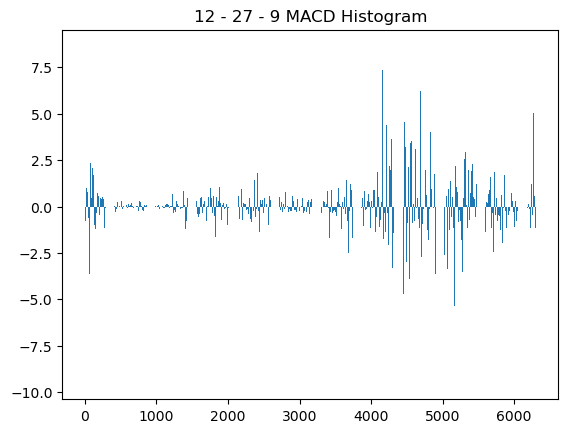

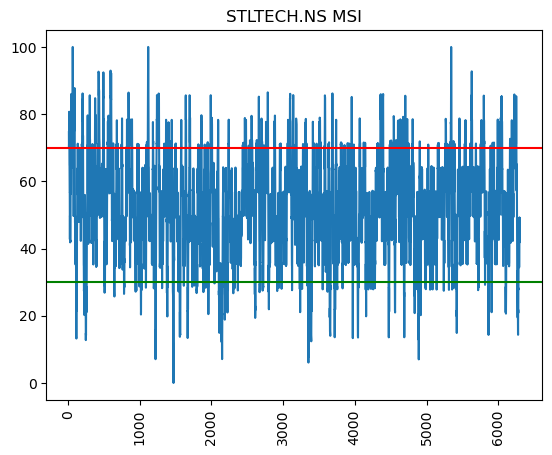

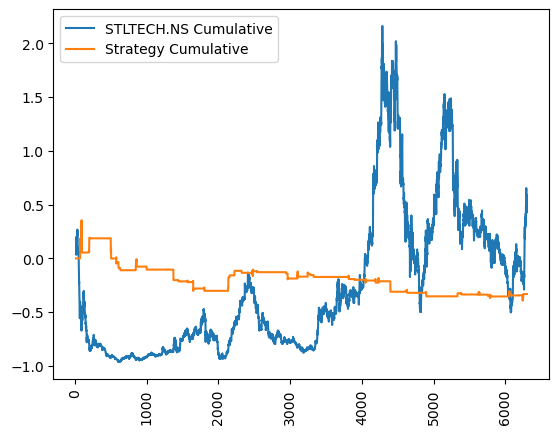

In [9]:
TICKER = 'STLTECH.NS'
MFI_LENGTH = 14
OVERBOUGHT = 70
OVERSOLD = 30 
PERIOD = '730d'
INTERVAL = '1d'
LOOKBACK = 10000
MACD_FAST = 12
MACD_SLOW = 27
MACD_SPAN = 9

def get_data(ticker=TICKER,lookback=LOOKBACK,interval=INTERVAL):


    df = yf.download(ticker,start='2000-01-01',interval=interval)
    df.columns = df.columns.get_level_values(0)

    #reset the index, so the weekends does not come in account
    df=df.reset_index(drop=True)

    return df.iloc[-lookback:, :]

def add_MACD(df, fast=MACD_FAST,slow=MACD_SLOW, span=MACD_SPAN):

    df[f'{fast}_ema'] = df['Close'].ewm(span=fast).mean()
    df[f'{slow}_ema'] = df['Close'].ewm(span=slow).mean()

    #macd line is the difference between the fast and slow
    df[f'MACD'] = df[f'{fast}_ema'] - df[f'{slow}_ema']

    #macd signal is a 9-period moving average of this line
    df['Signal'] = df['MACD'].ewm(span=span).mean()

    #macd histogram is almost always what is used in TA
    df['MACD_hist'] = df['MACD'] - df['Signal']

    #plot the histogram
    plt.bar(x=range(len(df)), height=df['MACD_hist'])
    plt.title(f'{MACD_FAST} - {MACD_SLOW} - {MACD_SPAN} MACD Histogram')

    return df

def add_MACD_strategy(df):

    df['MACD_Strategy'] = 0
    df['MACD_Strategy'] = np.where(df['MACD_hist'] < 0,1,-1)
    df['MACD_Strategy'] = df['MACD_Strategy'].shift(1)

    return df


def add_MFI(df, length=MFI_LENGTH):

    df['Average_Price'] = (df['High'] + df['Low'] + df['Close']) / 3
    df['Money_Flow'] = df['Volume'] * df['Average_Price']

    df['Pos_Flow'] = 0
    df['Neg_Flow'] = 0

    df['Pos_Flow'] = np.where(df['Average_Price'].diff() > 0, df['Average_Price'], 0)
    df['Neg_Flow'] = np.where(df['Average_Price'].diff() < 0, df['Average_Price'], 0)

    mfr = df['Pos_Flow'].rolling(length).sum() / df['Neg_Flow'].rolling(length).sum()

    df['MFI'] = (100 / (1+mfr))
    return df.dropna()


def add_MFI_strategy(df, overbought=OVERBOUGHT, oversold=OVERSOLD):
    
    df['MFI_Strategy'] = 0
    df['MFI_Strategy'] = np.where(df['MFI'] > overbought, -1,
                              np.where(df['MFI'] < oversold,1,0))
    
    df['MFI_Strategy'] = df['MFI_Strategy'].shift(1)

    plt.figure()
    plt.title(f'{TICKER} MSI')
    plt.plot(df['MFI'])
    plt.axhline(OVERBOUGHT,color='red')
    plt.axhline(OVERSOLD, color='green')
    plt.xticks(rotation='vertical')


    return df


def add_full_strategy(df):
    
    df['Full_Strategy'] = df['MACD_Strategy'] + df['MFI_Strategy']

    df['Strategy'] = np.where(df['Full_Strategy'] ==2, 1,
                     np.where(df['Full_Strategy'] == -2,-1,0 ))

    return df

def test_strategy(df):
    df['Asset_Returns'] = (1+df['Close'].pct_change()).cumprod() - 1
    df['Strategy_Returns'] = ( 1 + df['Close'].pct_change() * df['Strategy']).cumprod() - 1

    #plotting the strategy
    plt.figure()
    plt.plot(df['Asset_Returns'])
    plt.plot(df['Strategy_Returns'])
    plt.legend([f'{TICKER} Cumulative', 'Strategy Cumulative'])
    plt.xticks(rotation='vertical')

    return df


def main():
    df = get_data()
    df = add_MACD(df)
    df = add_MFI(df)

    df = add_MACD_strategy(df)
    df = add_MFI_strategy(df)

    df = add_full_strategy(df)

    df = test_strategy(df)

    return df

df = main()
df